# From Semiconductor Lasers to the Density of States

### A guided, hands-on journey through electronic states in solids

This notebook is a bridge between **theory** and **code**. The goal is didactic: we
start from a concrete device — the **semiconductor laser** — and we peel back the
layers of physics that make it work, writing small Python experiments at every step
so that each equation becomes something we can *see*.

Here is the path we will follow:

1. **Why semiconductor lasers?** — the motivation for caring about electronic states.
2. **Free electrons** — the simplest possible model, plane waves and the $E(k)$ parabola.
3. **Schrödinger for $V=0$** — solving the equation when nothing confines the electron.
4. **Electrons in a potential well** — confinement produces *discrete* energy levels.
5. **From real space to $k$-space** — the wave (reciprocal) picture and why it is convenient.
6. **Spherical shells in $k$-space** — counting states by volume.
7. **Density of states (DOS)** — how many states live near a given energy.
8. **Fermi–Dirac statistics** — how electrons *fill* those states, and the Fermi level $E_F$.
9. **DOS meets Fermi–Dirac at $T>0$** — the carrier population that actually matters.
10. **Macroscopic confinement in 2D** — a quantum well: two free directions, one quantized.
11. **Energy paraboloids** — visualizing $E_n(k) = E_n + \frac{\hbar^2 k^2}{2m}$.

Every section pairs a short narrative with a runnable cell. Read the text, run the code,
change the numbers, and watch the physics respond.

## 0. Setup

We only need `numpy`, `scipy` and `matplotlib`. We also define the physical constants
we will use throughout, in SI units, plus two handy conversion factors:

- `eV` — one electron-volt in joules, because band-structure energies are naturally
  expressed in eV;
- `m_eff` — the **effective mass** of an electron in GaAs
  ($m^* \approx 0.067\, m_e$). Inside a crystal the electron does not respond to
  forces with its bare mass: the periodic lattice potential "renormalizes" it. Using
  $m^*$ lets us keep the *free-electron formulas* while describing a *real
  semiconductor* — this trick is the reason the simple models below are so useful.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import cm

# --- Physical constants (SI) ---
hbar = 1.054571817e-34      # reduced Planck constant [J s]
m_e = 9.1093837015e-31      # free electron mass [kg]
eV = 1.602176634e-19        # 1 electron-volt [J]
k_B = 1.380649e-23          # Boltzmann constant [J/K]

# --- Effective mass in GaAs (conduction band) ---
m_eff = 0.067 * m_e

# A consistent look for all plots
plt.rcParams.update({
    "figure.figsize": (8, 5),
    "axes.grid": True,
    "grid.alpha": 0.3,
    "font.size": 11,
})

print(f"Effective mass in GaAs: m* = {m_eff:.3e} kg  ({m_eff/m_e:.3f} m_e)")
print(f"Thermal energy at 300 K: k_B T = {k_B*300/eV*1000:.1f} meV")

Effective mass in GaAs: m* = 6.103e-32 kg  (0.067 m_e)
Thermal energy at 300 K: k_B T = 25.9 meV


## 1. Why semiconductor lasers?

A **semiconductor laser** (laser diode) is, at its heart, a p–n junction where
electrons from the conduction band recombine with holes in the valence band and emit
photons. To get *laser* action — stimulated emission dominating over absorption — we
need **population inversion**: more electrons in high-energy states than would ever be
there at equilibrium.

Everything about this device is governed by three questions:

1. **Which energy states exist?** → the *band structure* and, under confinement,
   discrete levels. This is the job of the **Schrödinger equation**.
2. **How many states are there near a given energy?** → the **density of states (DOS)**,
   $g(E)$.
3. **Which of those states are occupied?** → the **Fermi–Dirac distribution**, $f(E)$,
   ruled by temperature and the **Fermi level** $E_F$.

The carrier density that produces gain is literally the product of the last two:

$$ n = \int g(E)\, f(E)\, dE $$

Modern laser diodes are **quantum well** devices: an ultra-thin (few nm) layer of a
low-bandgap material (e.g. GaAs) sandwiched between higher-bandgap barriers (e.g.
AlGaAs). The thin direction quantizes the electron motion, reshaping the DOS in a way
that *lowers the threshold current* and *sharpens the emission line*. By the end of the
notebook, we will see exactly how and why.

But we must build up to it. Let's start from the simplest object in quantum mechanics:
a **free electron**.

## 2. Free electrons and the Schrödinger equation for $V = 0$

The time-independent Schrödinger equation in one dimension reads

$$ -\frac{\hbar^2}{2m} \frac{d^2 \psi(x)}{dx^2} + V(x)\,\psi(x) = E\,\psi(x). $$

**Free** means $V(x) = 0$ everywhere: no walls, no potential, nothing pushing on the
electron. The equation collapses to

$$ \frac{d^2 \psi}{dx^2} = -\frac{2mE}{\hbar^2}\, \psi \equiv -k^2 \psi, $$

whose solutions are **plane waves**:

$$ \psi_k(x) = A\, e^{i k x}, \qquad k = \frac{\sqrt{2mE}}{\hbar}. $$

Two crucial observations:

- $k$ is the **wavenumber** ($k = 2\pi/\lambda$): the plane wave is the quantum
  version of "an electron traveling with momentum $p = \hbar k$". This is the de
  Broglie relation appearing naturally out of the math.
- Inverting the relation gives the **dispersion relation**

$$ E(k) = \frac{\hbar^2 k^2}{2m}, $$

  a **parabola** in $k$. There is no restriction on $k$: *any* value is allowed, so the
  energy spectrum is **continuous**. Keep this in mind — confinement is precisely what
  will break this continuity.

Note also that $|\psi_k(x)|^2 = |A|^2$ is *constant*: a free electron in a momentum
eigenstate is completely delocalized. Its position is maximally uncertain, exactly as
Heisenberg demands for a state with perfectly defined momentum.

Let's plot both the plane wave and the parabola.

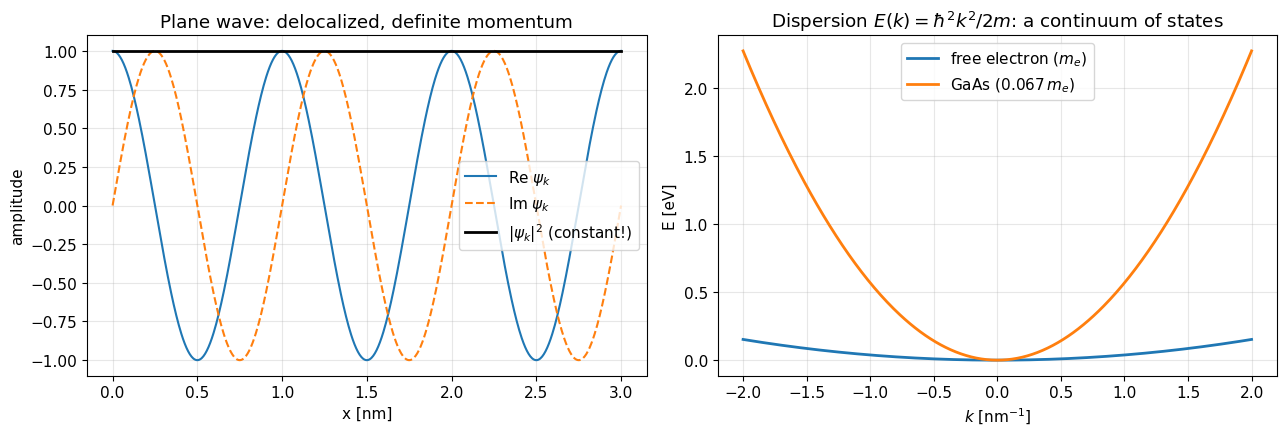

A free electron with lambda = 1 nm carries E = 1.50 eV


In [2]:
# --- A free electron: plane wave in real space + parabolic dispersion in k-space ---

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4.5))

# Left panel: the real and imaginary parts of psi_k(x) = e^{ikx}
# We pick a wavelength of 1 nm, i.e. k = 2*pi / (1 nm).
lam = 1e-9                          # wavelength [m]
k0 = 2 * np.pi / lam                # wavenumber [1/m]
x = np.linspace(0, 3e-9, 600)       # 3 nm of space

psi = np.exp(1j * k0 * x)           # the plane wave (A = 1)
ax1.plot(x * 1e9, psi.real, label=r"Re $\psi_k$")
ax1.plot(x * 1e9, psi.imag, "--", label=r"Im $\psi_k$")
ax1.plot(x * 1e9, np.abs(psi) ** 2, "k", lw=2, label=r"$|\psi_k|^2$ (constant!)")
ax1.set_xlabel("x [nm]")
ax1.set_ylabel("amplitude")
ax1.set_title("Plane wave: delocalized, definite momentum")
ax1.legend()

# Right panel: E(k) parabola, for the bare mass and the GaAs effective mass.
# The lighter effective mass makes the parabola *steeper*: same k, more energy.
k = np.linspace(-2e9, 2e9, 400)     # k range [1/m], i.e. +/- 2 nm^-1

for m, label in [(m_e, r"free electron ($m_e$)"), (m_eff, r"GaAs ($0.067\,m_e$)")]:
    E = (hbar * k) ** 2 / (2 * m) / eV    # energy in eV
    ax2.plot(k * 1e-9, E, lw=2, label=label)

ax2.set_xlabel(r"$k$ [nm$^{-1}$]")
ax2.set_ylabel("E [eV]")
ax2.set_title(r"Dispersion $E(k) = \hbar^2 k^2 / 2m$: a continuum of states")
ax2.legend()

plt.tight_layout()
plt.show()

E_at_1nm = (hbar * k0) ** 2 / (2 * m_e) / eV
print(f"A free electron with lambda = 1 nm carries E = {E_at_1nm:.2f} eV")

## 3. Confinement: the electron in a potential well

Now we trap the electron. The cleanest model is the **infinite potential well** (also
called "particle in a box"): the potential is zero inside a region of width $L$ and
infinite outside,

$$ V(x) = \begin{cases} 0 & 0 < x < L \\ \infty & \text{elsewhere.} \end{cases} $$

Inside the box the Schrödinger equation is *the same free-electron equation* as before
— but now the wavefunction must **vanish at the walls** ($\psi(0)=\psi(L)=0$), because
the electron cannot exist where the potential is infinite. A plane wave alone cannot
satisfy this; a **standing wave** can:

$$ \psi_n(x) = \sqrt{\tfrac{2}{L}} \sin\!\left(\frac{n \pi x}{L}\right), \qquad n = 1, 2, 3, \dots $$

The boundary conditions only accept wavenumbers $k_n = n\pi/L$: **$k$ is no longer
free**. Plugging $k_n$ into the free-electron parabola gives **discrete energies**:

$$ E_n = \frac{\hbar^2 k_n^2}{2m} = \frac{n^2 \pi^2 \hbar^2}{2 m L^2}. $$

This is the essence of quantum confinement, and three features deserve attention:

- **Quantization comes from boundary conditions**, not from a new equation. Same
  physics, different geometry.
- Energies grow like $n^2$, so levels spread apart as you go up.
- $E_n \propto 1/L^2$: *the smaller the box, the higher (and more separated) the
  levels*. A 10 nm well in GaAs has level spacings of tens of meV — comparable to
  $k_B T$ at room temperature, which is exactly why nanometric layers show quantum
  behavior in everyday devices.

The cell below draws the "textbook picture": levels inside the well with their standing
waves, and it verifies the $1/L^2$ scaling numerically.

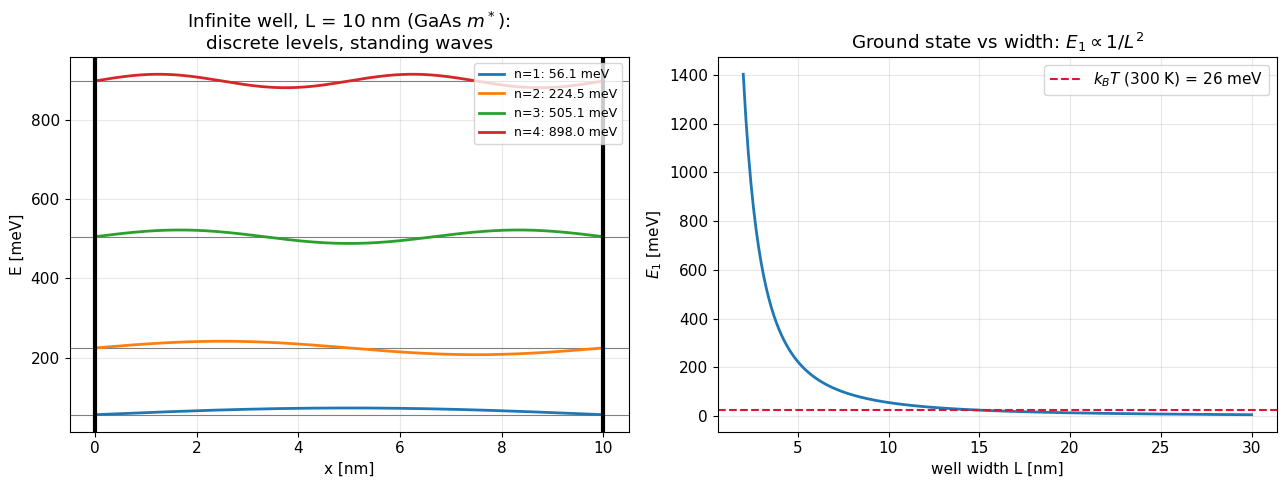

Level spacing E2 - E1 for L = 10 nm: 168.4 meV -> comparable to k_B T: confinement matters at room temperature!


In [3]:
# --- Infinite well: discrete levels and standing waves ---

L = 10e-9   # well width: 10 nm (a realistic quantum-well thickness)


def E_well(n, L, m):
    """Energy of level n in an infinite well of width L, in joules."""
    return (n * np.pi * hbar) ** 2 / (2 * m * L ** 2)


def psi_well(n, x, L):
    """Normalized standing wave of level n."""
    return np.sqrt(2 / L) * np.sin(n * np.pi * x / L)


x = np.linspace(0, L, 500)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))

# Left: energy levels with the wavefunction drawn "sitting" on each level.
# The wavefunction is rescaled only for visual clarity.
for n in range(1, 5):
    En = E_well(n, L, m_eff) / eV * 1000          # meV
    scale = 12                                     # visual amplitude in meV
    ax1.axhline(En, color="gray", lw=0.8)
    ax1.plot(x * 1e9, En + scale * psi_well(n, x, L) * np.sqrt(L),
             lw=2, label=f"n={n}: {En:.1f} meV")

ax1.axvline(0, color="k", lw=3)
ax1.axvline(L * 1e9, color="k", lw=3)
ax1.set_xlabel("x [nm]")
ax1.set_ylabel("E [meV]")
ax1.set_title(f"Infinite well, L = {L*1e9:.0f} nm (GaAs $m^*$):\ndiscrete levels, standing waves")
ax1.legend(loc="upper right", fontsize=9)

# Right: the 1/L^2 scaling of the ground state.
# Halving the width quadruples the confinement energy.
widths = np.linspace(2e-9, 30e-9, 200)
E1 = E_well(1, widths, m_eff) / eV * 1000
ax2.plot(widths * 1e9, E1, lw=2)
ax2.set_xlabel("well width L [nm]")
ax2.set_ylabel(r"$E_1$ [meV]")
ax2.set_title(r"Ground state vs width: $E_1 \propto 1/L^2$")

# Mark k_B T at 300 K as the "thermal ruler"
kT_meV = k_B * 300 / eV * 1000
ax2.axhline(kT_meV, color="crimson", ls="--", label=f"$k_B T$ (300 K) = {kT_meV:.0f} meV")
ax2.legend()

plt.tight_layout()
plt.show()

print("Level spacing E2 - E1 for L = 10 nm:",
      f"{(E_well(2, L, m_eff) - E_well(1, L, m_eff))/eV*1000:.1f} meV",
      "-> comparable to k_B T: confinement matters at room temperature!")

## 4. Changing reference frame: from real space to $k$-space

So far we have described states by their wavefunction in **real space**, $\psi(x)$. But
notice what actually *labels* a state: not $x$, but the wavenumber $k$ (or the triple
$\mathbf{k} = (k_x, k_y, k_z)$ in three dimensions). Energy, momentum, group velocity —
everything is a function of $\mathbf{k}$. It is therefore natural to switch to a
**reference frame whose axes are $k_x, k_y, k_z$**: this is called **$k$-space** (or
reciprocal space), and it is *the* natural habitat of solid-state physics.

Why is this so powerful? Consider a macroscopic crystal, a cube of side $L_{box}$
(millimeters — enormous compared to atomic scales). Imposing periodic boundary
conditions, $\psi(x + L_{box}) = \psi(x)$, the allowed plane waves must satisfy

$$ k_i = \frac{2\pi}{L_{box}}\, n_i, \qquad n_i \in \mathbb{Z}, \quad i = x, y, z. $$

So in $k$-space the allowed states form a **regular cubic grid** with spacing
$\Delta k = 2\pi/L_{box}$. Each state occupies a tiny cell of volume

$$ \left(\frac{2\pi}{L_{box}}\right)^3 = \frac{(2\pi)^3}{V}, $$

where $V = L_{box}^3$. Because $L_{box}$ is macroscopic, the grid is *incredibly* fine —
so fine that we can treat it as a continuum and **count states by measuring volumes in
$k$-space**:

$$ N_{\text{states}} = 2 \times \frac{\text{k-space volume}}{(2\pi)^3 / V}, $$

where the factor $2$ accounts for the two **spin** orientations of the electron.

**Key geometric insight**: the energy $E = \hbar^2 |\mathbf{k}|^2 / 2m$ depends only on
the *magnitude* of $\mathbf{k}$. Therefore all states with the same energy sit on a
**sphere** in $k$-space, and all states with energy *up to* $E$ fill a **ball** of
radius $k = \sqrt{2mE}/\hbar$. Counting states below energy $E$ becomes computing the
volume of a sphere — this is the "spherical representation in $k$" and it is the whole
trick behind the density of states.

Let's visualize the grid and the spherical shells.

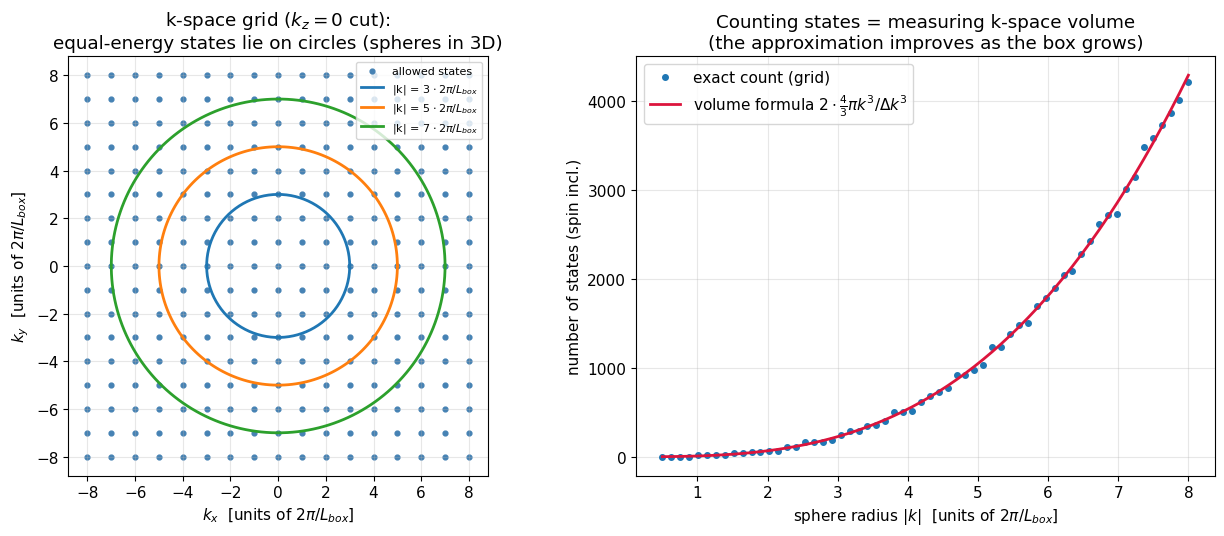

In [4]:
# --- k-space: the grid of allowed states and the constant-energy sphere ---
# For the drawing we use a deliberately SMALL box, so the grid is visible.
# In a real crystal the grid would be ~10^7 times denser.

fig = plt.figure(figsize=(13, 5.5))

# Left: 2D cut (kz = 0) of the grid, with circles of constant energy.
ax1 = fig.add_subplot(1, 2, 1)
n_max = 8
n = np.arange(-n_max, n_max + 1)
KX, KY = np.meshgrid(n, n)                    # grid indices n_x, n_y
ax1.scatter(KX, KY, s=12, color="steelblue", label="allowed states")

# Constant-energy circles: |k| = const  <=>  E = const
for radius in [3, 5, 7]:
    theta = np.linspace(0, 2 * np.pi, 200)
    ax1.plot(radius * np.cos(theta), radius * np.sin(theta), lw=2,
             label=f"|k| = {radius} " + r"$\cdot \, 2\pi/L_{box}$")

ax1.set_xlabel(r"$k_x$  [units of $2\pi/L_{box}$]")
ax1.set_ylabel(r"$k_y$  [units of $2\pi/L_{box}$]")
ax1.set_title("k-space grid ($k_z = 0$ cut):\nequal-energy states lie on circles (spheres in 3D)")
ax1.set_aspect("equal")
ax1.legend(fontsize=8, loc="upper right")

# Right: count states inside a ball of radius k and compare with the
# analytic volume formula  N(k) = 2 * (4/3 pi k^3) / (2pi/L)^3 (spin included).
ax2 = fig.add_subplot(1, 2, 2)
nx, ny, nz = np.meshgrid(n, n, n)
k_norm = np.sqrt(nx**2 + ny**2 + nz**2)       # |k| in grid units

radii = np.linspace(0.5, n_max, 60)
counted = [2 * np.sum(k_norm <= r) for r in radii]          # brute-force count
analytic = 2 * (4 / 3) * np.pi * radii ** 3                 # volume estimate

ax2.plot(radii, counted, "o", ms=4, label="exact count (grid)")
ax2.plot(radii, analytic, lw=2, color="crimson",
         label=r"volume formula $2 \cdot \frac{4}{3}\pi k^3 / \Delta k^3$")
ax2.set_xlabel(r"sphere radius $|k|$  [units of $2\pi/L_{box}$]")
ax2.set_ylabel("number of states (spin incl.)")
ax2.set_title("Counting states = measuring k-space volume\n(the approximation improves as the box grows)")
ax2.legend()

plt.tight_layout()
plt.show()

## 5. The density of states (DOS) in 3D

We can now answer question #2 from the introduction: *how many states are available
near a given energy?*

The number of states (per unit volume of crystal, spin included) inside the ball of
radius $k$ is

$$ n(k) = \frac{2}{V} \cdot \frac{\frac{4}{3}\pi k^3}{(2\pi)^3/V} = \frac{k^3}{3\pi^2}. $$

Substituting $k = \sqrt{2mE}/\hbar$ gives the number of states with energy below $E$:

$$ n(E) = \frac{1}{3\pi^2} \left( \frac{2mE}{\hbar^2} \right)^{3/2}. $$

The **density of states** is its derivative — the number of states in a thin spherical
*shell* between $E$ and $E + dE$:

$$ \boxed{\; g_{3D}(E) = \frac{dn}{dE} = \frac{1}{2\pi^2} \left( \frac{2m}{\hbar^2} \right)^{3/2} \sqrt{E} \;} $$

The famous **square-root DOS**. Its shape has a simple geometric reading: as $E$ grows,
the constant-energy sphere grows, and a shell of fixed thickness $dE$ contains more and
more states — but only like $\sqrt{E}$, because the shell also gets thinner in $k$
($dE \propto k\,dk$).

At $T = 0$, electrons fill these states from the bottom up (Pauli exclusion: one
electron per state). The energy of the *last filled state* is the **Fermi energy**
$E_F$. Requiring that the filled ball contains exactly the electron density $n_e$ gives

$$ E_F = \frac{\hbar^2}{2m} \left( 3\pi^2 n_e \right)^{2/3}, $$

and the corresponding sphere in $k$-space is the **Fermi sphere**, with radius
$k_F = (3\pi^2 n_e)^{1/3}$. Everything below $E_F$ is occupied; everything above is
empty. That sharp boundary is about to get "smeared" by temperature — that is the job
of Fermi–Dirac statistics in the next section.

Carrier density  n_e = 2.0e+18 cm^-3
Fermi energy     E_F = 86.4 meV above the band edge


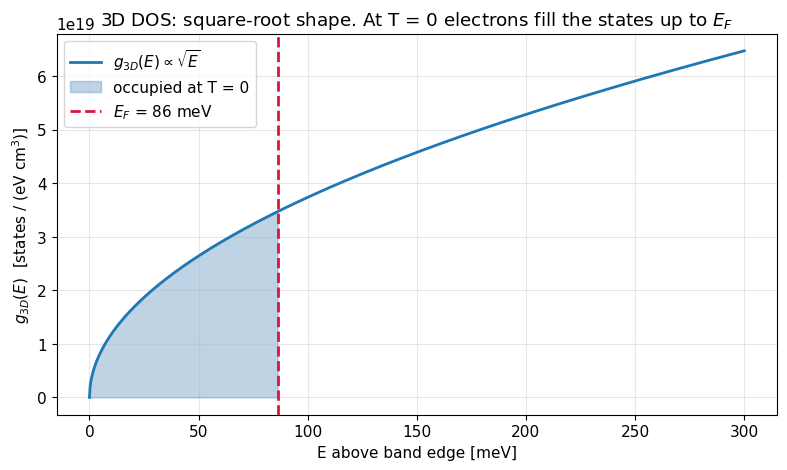

Integral of g(E) up to E_F: 2.000e+24 m^-3  (target: 2.000e+24) -> consistent


In [5]:
# --- 3D density of states and the Fermi level at T = 0 ---

def dos_3d(E, m):
    """3D density of states per unit volume [states / (J m^3)], spin included.
    E in joules; negative energies get zero states."""
    E = np.asarray(E, dtype=float)
    g = np.zeros_like(E)
    pos = E > 0
    g[pos] = (1 / (2 * np.pi**2)) * (2 * m / hbar**2) ** 1.5 * np.sqrt(E[pos])
    return g


def fermi_energy_3d(n_e, m):
    """Fermi energy [J] of a 3D electron gas of density n_e [1/m^3]."""
    return hbar**2 / (2 * m) * (3 * np.pi**2 * n_e) ** (2 / 3)


# A typical carrier density injected in a laser diode's active region
n_e = 2e24                                   # electrons per m^3 (= 2e18 cm^-3)
E_F = fermi_energy_3d(n_e, m_eff)
print(f"Carrier density  n_e = {n_e*1e-6:.1e} cm^-3")
print(f"Fermi energy     E_F = {E_F/eV*1000:.1f} meV above the band edge")

E = np.linspace(0, 0.3, 1000) * eV           # energy axis: 0 to 300 meV
g = dos_3d(E, m_eff)

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(E / eV * 1000, g * eV * 1e-6, lw=2, label=r"$g_{3D}(E) \propto \sqrt{E}$")

# Shade the occupied states at T = 0: everything below E_F
occupied = E <= E_F
ax.fill_between(E[occupied] / eV * 1000, g[occupied] * eV * 1e-6,
                alpha=0.35, color="steelblue", label="occupied at T = 0")
ax.axvline(E_F / eV * 1000, color="crimson", ls="--", lw=2,
           label=f"$E_F$ = {E_F/eV*1000:.0f} meV")

ax.set_xlabel("E above band edge [meV]")
ax.set_ylabel(r"$g_{3D}(E)$  [states / (eV cm$^3$)]")
ax.set_title("3D DOS: square-root shape. At T = 0 electrons fill the states up to $E_F$")
ax.legend()
plt.tight_layout()
plt.show()

# Sanity check: integrating g(E) up to E_F must return the electron density.
from scipy.integrate import quad
n_check, _ = quad(lambda e: dos_3d(e, m_eff), 0, E_F)
print(f"Integral of g(E) up to E_F: {n_check:.3e} m^-3  (target: {n_e:.3e}) -> consistent")

## 6. Fermi–Dirac statistics: how electrons occupy the states

Electrons are **fermions**: no two of them can share the same quantum state (Pauli
exclusion principle). At thermal equilibrium at temperature $T$, the probability that a
state of energy $E$ is occupied is given by the **Fermi–Dirac distribution**:

$$ \boxed{\; f(E) = \frac{1}{e^{(E - E_F)/k_B T} + 1} \;} $$

where $E_F$ is the Fermi level (more precisely the chemical potential $\mu$, but at the
temperatures we care about the distinction is negligible). Read it limit by limit:

- **$T \to 0$**: the exponential jumps from $0$ to $\infty$ exactly at $E = E_F$, so
  $f(E)$ becomes a perfect **step**: $1$ below $E_F$, $0$ above. This is the filled
  Fermi sphere of the previous section.
- **$T > 0$**: the step **smears** over an energy window of width $\sim k_B T$ around
  $E_F$ (about 26 meV at room temperature). Some electrons just below $E_F$ are
  thermally promoted just above it. Note the exact symmetry:
  $f(E_F + \delta) = 1 - f(E_F - \delta)$ — every electron that appears above the Fermi
  level leaves a **hole** below it.
- **$E - E_F \gg k_B T$**: the $+1$ in the denominator becomes irrelevant and
  $f(E) \approx e^{-(E-E_F)/k_B T}$ — the classical **Boltzmann tail**, which is why
  non-degenerate semiconductors can often be treated classically.

The point of $f(E)$ is that it is *universal*: it does not know anything about the
material. All the material information sits in $g(E)$. The two will be combined in the
next section.

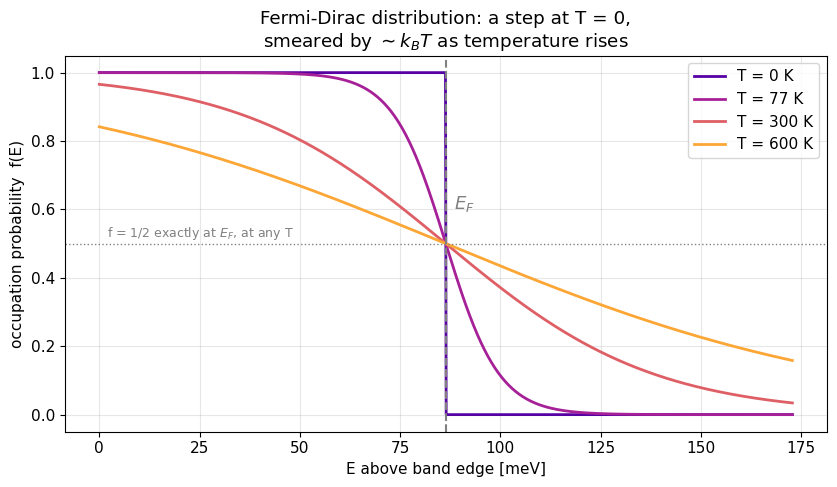

T =   77 K:  k_B T =   6.6 meV   ( 7.7% of E_F)
T =  300 K:  k_B T =  25.9 meV   (29.9% of E_F)
T =  600 K:  k_B T =  51.7 meV   (59.8% of E_F)


In [6]:
# --- The Fermi-Dirac distribution at different temperatures ---

def fermi_dirac(E, E_F, T):
    """Occupation probability of a state at energy E [J].
    Handles T = 0 as an exact step function."""
    E = np.asarray(E, dtype=float)
    if T == 0:
        return np.where(E <= E_F, 1.0, 0.0)
    return 1.0 / (np.exp((E - E_F) / (k_B * T)) + 1.0)


E = np.linspace(0, 2 * E_F, 1000)
temperatures = [0, 77, 300, 600]              # K: absolute zero, liquid N2, room, hot
colors = cm.plasma(np.linspace(0.15, 0.8, len(temperatures)))

fig, ax = plt.subplots(figsize=(8.5, 5))
for T, c in zip(temperatures, colors):
    ax.plot(E / eV * 1000, fermi_dirac(E, E_F, T), lw=2, color=c, label=f"T = {T} K")

ax.axvline(E_F / eV * 1000, color="gray", ls="--", lw=1.5)
ax.text(E_F / eV * 1000 + 2, 0.6, r"$E_F$", color="gray", fontsize=13)
ax.axhline(0.5, color="gray", ls=":", lw=1)
ax.text(2, 0.52, "f = 1/2 exactly at $E_F$, at any T", color="gray", fontsize=9)

ax.set_xlabel("E above band edge [meV]")
ax.set_ylabel("occupation probability  f(E)")
ax.set_title("Fermi-Dirac distribution: a step at T = 0,\nsmeared by $\\sim k_B T$ as temperature rises")
ax.legend()
plt.tight_layout()
plt.show()

# The smearing window compared to E_F
for T in temperatures[1:]:
    print(f"T = {T:4d} K:  k_B T = {k_B*T/eV*1000:5.1f} meV   "
          f"({k_B*T/E_F*100:4.1f}% of E_F)")

## 7. Putting them together: DOS $\times$ Fermi–Dirac at $T > 0$

Here is the conceptual heart of the notebook. The density of **occupied** states — the
electrons that actually exist, carry current, and recombine to emit photons — is the
product of the two functions we built:

$$ n(E)\,dE = \underbrace{g(E)}_{\text{available states}} \times \underbrace{f(E)}_{\text{occupation probability}} \, dE, \qquad n_e = \int_0^\infty g(E)\, f(E)\, dE. $$

What happens when we switch on the temperature?

- At $T=0$ the electron distribution is $g(E)$ *sharply cut* at $E_F$.
- At $T>0$ the cut becomes a smooth shoulder: states within $\sim k_B T$ **below** $E_F$
  lose some electrons, and states within $\sim k_B T$ **above** $E_F$ gain them. Only
  this thin shell participates in thermal physics — the deep states are "frozen" by
  Pauli exclusion, since all neighboring states are already full.
- The **total area under the curve is fixed** (electron number is conserved); if the
  density is held constant, the chemical potential drifts slightly with $T$ to keep the
  integral constant. For our qualitative plot we keep $E_F$ fixed, which is accurate to
  first order.

For a laser, this product is directly related to the **gain spectrum**: photon emission
at energy $h\nu$ needs full states in the conduction band and empty states in the
valence band, and both populations are exactly objects of the form $g \cdot f$.

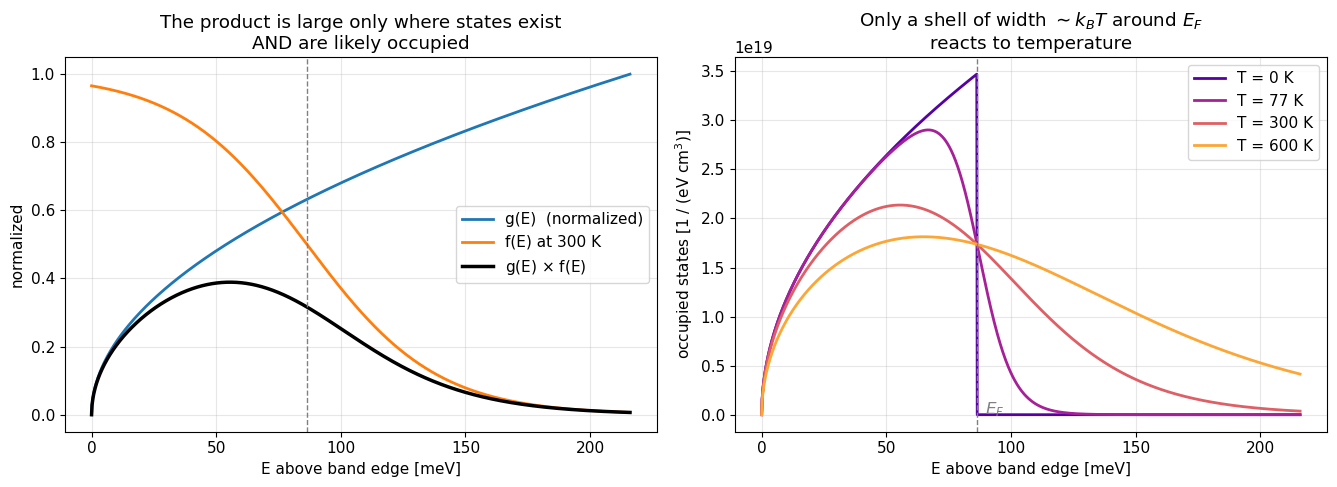

T =    0 K -> integral g*f = 2.000e+24 m^-3   ( +0.0% vs T=0 density)
T =   77 K -> integral g*f = 2.015e+24 m^-3   ( +0.7% vs T=0 density)
T =  300 K -> integral g*f = 2.228e+24 m^-3   (+11.4% vs T=0 density)
T =  600 K -> integral g*f = 2.664e+24 m^-3   (+33.2% vs T=0 density)


In [7]:
# --- Occupied states n(E) = g(E) * f(E) at increasing temperature ---

E = np.linspace(0, 2.5 * E_F, 1200)
g = dos_3d(E, m_eff)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13.5, 5))

# Left: the three ingredients at T = 300 K, on normalized scales,
# to see WHERE the product is large.
T_show = 300
f300 = fermi_dirac(E, E_F, T_show)
ax1.plot(E / eV * 1000, g / g.max(), lw=2, label="g(E)  (normalized)")
ax1.plot(E / eV * 1000, f300, lw=2, label=f"f(E) at {T_show} K")
ax1.plot(E / eV * 1000, g * f300 / g.max(), lw=2.5, color="k",
         label=r"g(E) $\times$ f(E)")
ax1.axvline(E_F / eV * 1000, color="gray", ls="--", lw=1)
ax1.set_xlabel("E above band edge [meV]")
ax1.set_ylabel("normalized")
ax1.set_title("The product is large only where states exist\nAND are likely occupied")
ax1.legend()

# Right: the occupied-state distribution as T grows.
for T, c in zip(temperatures, colors):
    occ = g * fermi_dirac(E, E_F, T)
    ax2.plot(E / eV * 1000, occ * eV * 1e-6, lw=2, color=c, label=f"T = {T} K")

ax2.axvline(E_F / eV * 1000, color="gray", ls="--", lw=1)
ax2.text(E_F / eV * 1000 + 3, 0.4e18 * 1e-18, r"$E_F$", color="gray", fontsize=12)
ax2.set_xlabel("E above band edge [meV]")
ax2.set_ylabel(r"occupied states [1 / (eV cm$^3$)]")
ax2.set_title("Only a shell of width $\\sim k_B T$ around $E_F$\nreacts to temperature")
ax2.legend()

plt.tight_layout()
plt.show()

# Electron density vs temperature at fixed E_F (shows the small drift
# a real chemical potential would compensate).
from scipy.integrate import simpson
for T in temperatures:
    n_T = simpson(g * fermi_dirac(E, E_F, T), x=E)
    print(f"T = {T:4d} K -> integral g*f = {n_T:.3e} m^-3   "
          f"({(n_T-n_e)/n_e*100:+5.1f}% vs T=0 density)")

## 8. Macroscopic confinement: the quantum well (2D electron gas)

Now the step that turns all this theory into **laser engineering**. Take the crystal
and squeeze **one** direction — say $z$ — down to a few nanometers, while $x$ and $y$
remain macroscopic. This is a **quantum well**: exactly the structure grown by
epitaxy in a modern laser diode (a thin GaAs layer between AlGaAs barriers).

The Schrödinger equation separates: the motion splits into a *confined* part and a
*free* part.

- Along $z$: a particle-in-a-box problem of width $L_z$ → **discrete levels**
  $E_n = \dfrac{n^2 \pi^2 \hbar^2}{2 m L_z^2}$.
- Along $x, y$: free plane waves → a **continuous parabola** in
  $k_\parallel = (k_x, k_y)$.

The total eigenvalue of the Schrödinger equation is the sum of the two:

$$ \boxed{\; E_n(\mathbf{k}_\parallel) = E_n + \frac{\hbar^2 (k_x^2 + k_y^2)}{2m} \;} $$

Each discrete level $E_n$ becomes the bottom of a **subband**: a paraboloid of
revolution in $(k_x, k_y, E)$ space, sitting at height $E_n$. The electron gas living
in these subbands is called a **two-dimensional electron gas (2DEG)**.

The DOS changes shape dramatically. Repeating the state-counting argument in 2D —
circles instead of spheres, areas instead of volumes — each subband contributes a
**constant** density of states (per unit area, spin included):

$$ g_{2D}(E) = \frac{m}{\pi \hbar^2} \quad \text{per subband}, $$

so the total DOS is a **staircase**:

$$ g_{QW}(E) = \frac{m}{\pi \hbar^2} \sum_n \Theta(E - E_n), $$

where $\Theta$ is the Heaviside step function. Compare with the 3D square root: in a
quantum well the DOS is *already at full height right at the band edge* $E_1$, instead
of starting from zero. Electrons injected into the well pile up exactly where the laser
transition happens — this is why quantum-well lasers have a lower threshold current and
a narrower gain spectrum than bulk ones.

Let's compute the subbands for a 10 nm GaAs well and draw the staircase against the 3D
square root.

Subband bottom E_1 =   56.1 meV
Subband bottom E_2 =  224.5 meV
Subband bottom E_3 =  505.1 meV


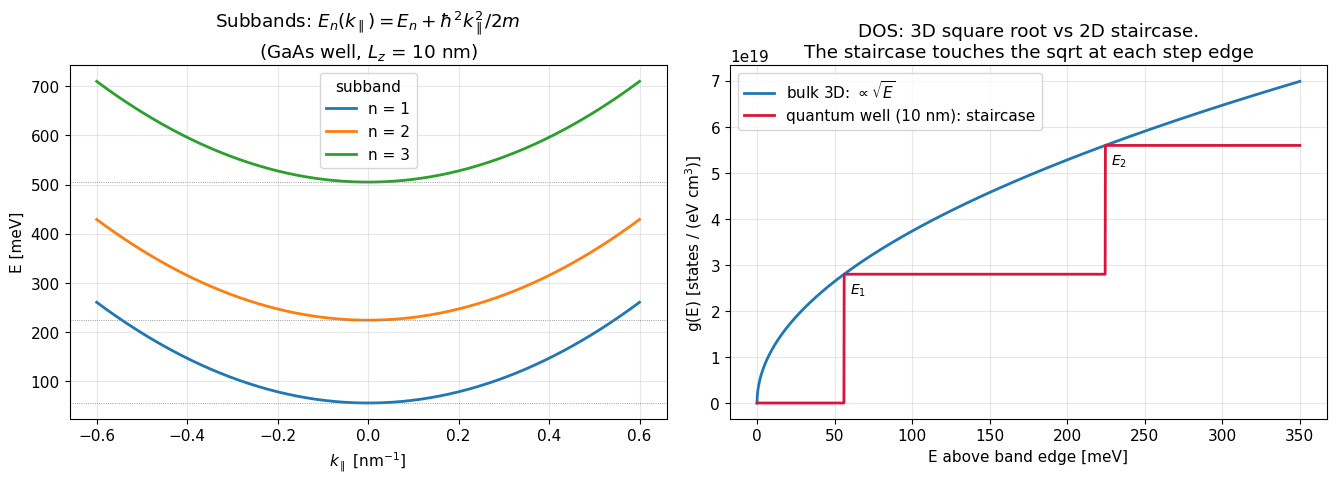


2D DOS per subband: g_2D = m*/(pi hbar^2) = 2.80e+13 states / (eV cm^2)


In [8]:
# --- Quantum well: subband dispersions and the staircase DOS ---

L_z = 10e-9                                  # well thickness: 10 nm
subbands = [E_well(n, L_z, m_eff) for n in (1, 2, 3)]
for n, En in enumerate(subbands, start=1):
    print(f"Subband bottom E_{n} = {En/eV*1000:6.1f} meV")

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13.5, 5))

# Left: E_n(k_par) = E_n + hbar^2 k_par^2 / 2m -- a family of nested parabolas.
k_par = np.linspace(-0.6e9, 0.6e9, 400)      # in-plane |k| [1/m]
for n, En in enumerate(subbands, start=1):
    E_disp = (En + (hbar * k_par) ** 2 / (2 * m_eff)) / eV * 1000
    ax1.plot(k_par * 1e-9, E_disp, lw=2, label=f"n = {n}")
    ax1.axhline(En / eV * 1000, color="gray", lw=0.6, ls=":")

ax1.set_xlabel(r"$k_\parallel$ [nm$^{-1}$]")
ax1.set_ylabel("E [meV]")
ax1.set_title(r"Subbands: $E_n(k_\parallel) = E_n + \hbar^2 k_\parallel^2 / 2m$"
              + f"\n(GaAs well, $L_z$ = {L_z*1e9:.0f} nm)")
ax1.legend(title="subband")

# Right: the 2D staircase DOS vs the 3D square root.
# To compare them we express the 2D DOS per unit VOLUME by dividing by L_z.
E_axis = np.linspace(0, 0.35, 2000) * eV
g2d_step = m_eff / (np.pi * hbar**2)         # per subband, per unit area
g_qw = np.zeros_like(E_axis)
for En in subbands:
    g_qw += np.where(E_axis >= En, g2d_step, 0.0)
g_qw_volume = g_qw / L_z                     # per unit volume, to compare with 3D

ax2.plot(E_axis / eV * 1000, dos_3d(E_axis, m_eff) * eV * 1e-6, lw=2,
         label="bulk 3D: $\\propto \\sqrt{E}$")
ax2.plot(E_axis / eV * 1000, g_qw_volume * eV * 1e-6, lw=2, color="crimson",
         label=f"quantum well ({L_z*1e9:.0f} nm): staircase")
for n, En in enumerate(subbands, start=1):
    ax2.annotate(f"$E_{n}$", (En / eV * 1000, n * g2d_step / L_z * eV * 1e-6),
                 textcoords="offset points", xytext=(4, -14), fontsize=10)

ax2.set_xlabel("E above band edge [meV]")
ax2.set_ylabel(r"g(E) [states / (eV cm$^3$)]")
ax2.set_title("DOS: 3D square root vs 2D staircase.\nThe staircase touches the sqrt at each step edge")
ax2.legend()

plt.tight_layout()
plt.show()

print(f"\n2D DOS per subband: g_2D = m*/(pi hbar^2) = "
      f"{g2d_step * eV * 1e-4:.2e} states / (eV cm^2)")

## 9. Energy paraboloids: the subbands in 3D

The formula $E_n(\mathbf{k}_\parallel) = E_n + \frac{\hbar^2(k_x^2 + k_y^2)}{2m}$ is
best appreciated as a **surface** over the $(k_x, k_y)$ plane. Since the kinetic term
depends only on $k_x^2 + k_y^2 = |k_\parallel|^2$, each surface is a **paraboloid of
revolution**:

- its **vertex** sits at $(0, 0, E_n)$ — the confinement energy of subband $n$;
- its **curvature** is set by $\hbar^2/2m^*$, i.e. by the effective mass, and it is the
  *same* for all subbands: the paraboloids are identical copies, just shifted up by
  $E_n$;
- **cutting it with a horizontal plane** $E = \text{const}$ produces a circle — exactly
  the constant-energy circles we drew in $k$-space in section 4. This closes the loop
  between the 2D grid picture and the 3D dispersion picture.

The plot below shows the first three paraboloids, plus a constant-energy plane to make
the circular cross-sections visible.

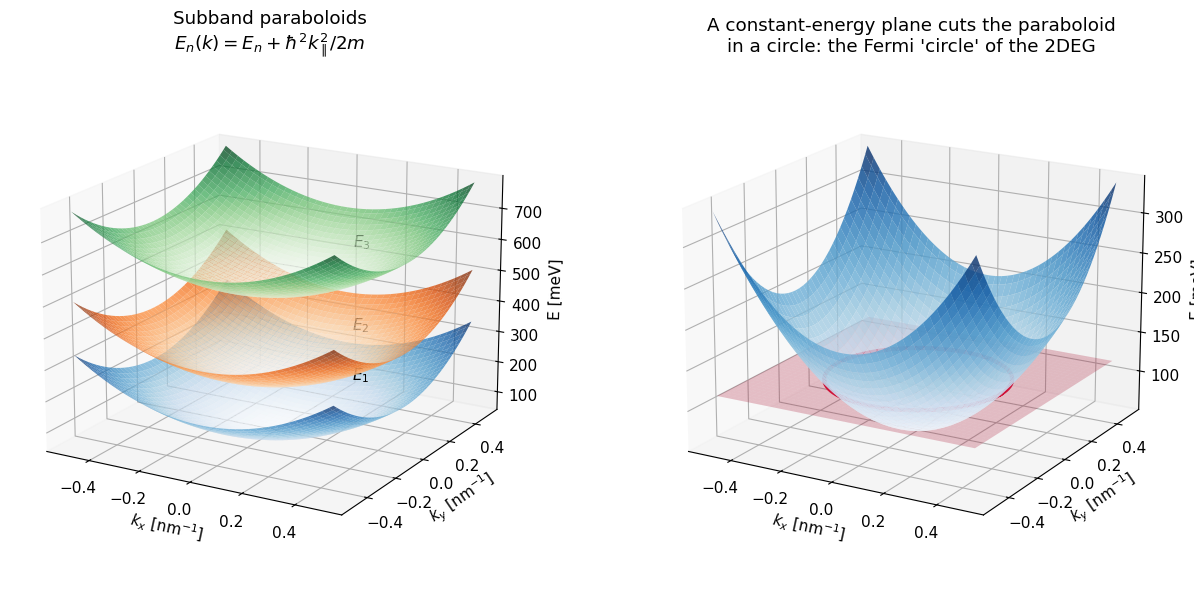

Cut at E_1 + 60 meV -> circle radius k = 0.325 nm^-1


In [9]:
# --- 3D visualization: energy paraboloids of the first three subbands ---

kx = np.linspace(-0.5e9, 0.5e9, 120)
ky = np.linspace(-0.5e9, 0.5e9, 120)
KX, KY = np.meshgrid(kx, ky)
kinetic = (hbar**2 * (KX**2 + KY**2)) / (2 * m_eff) / eV * 1000   # meV

fig = plt.figure(figsize=(13, 6))

# Left: the three nested paraboloids.
ax1 = fig.add_subplot(1, 2, 1, projection="3d")
cmaps = [cm.Blues, cm.Oranges, cm.Greens]
for (n, En), cmap in zip(enumerate(subbands, start=1), cmaps):
    E_surface = En / eV * 1000 + kinetic
    ax1.plot_surface(KX * 1e-9, KY * 1e-9, E_surface,
                     cmap=cmap, alpha=0.75, linewidth=0, antialiased=True)
    ax1.text(0, 0.55, En / eV * 1000, f"$E_{n}$", fontsize=11)

ax1.set_xlabel(r"$k_x$ [nm$^{-1}$]")
ax1.set_ylabel(r"$k_y$ [nm$^{-1}$]")
ax1.set_zlabel("E [meV]")
ax1.set_title("Subband paraboloids\n$E_n(k) = E_n + \\hbar^2 k_\\parallel^2/2m$")
ax1.view_init(elev=18, azim=-60)

# Right: first paraboloid cut by a constant-energy plane ->
# the intersection is a circle (the constant-energy contour in k-space).
ax2 = fig.add_subplot(1, 2, 2, projection="3d")
E1_meV = subbands[0] / eV * 1000
surf1 = E1_meV + kinetic
ax2.plot_surface(KX * 1e-9, KY * 1e-9, surf1, cmap=cm.Blues,
                 alpha=0.8, linewidth=0)

E_cut = E1_meV + 60                            # cutting plane: E_1 + 60 meV
ax2.plot_surface(KX * 1e-9, KY * 1e-9, np.full_like(KX, E_cut),
                 color="crimson", alpha=0.25, linewidth=0)

# The intersection circle: hbar^2 k^2 / 2m = 60 meV  ->  k_circle
k_circle = np.sqrt(2 * m_eff * 60e-3 * eV) / hbar
theta = np.linspace(0, 2 * np.pi, 200)
ax2.plot(k_circle * np.cos(theta) * 1e-9, k_circle * np.sin(theta) * 1e-9,
         np.full_like(theta, E_cut), color="crimson", lw=3)

ax2.set_xlabel(r"$k_x$ [nm$^{-1}$]")
ax2.set_ylabel(r"$k_y$ [nm$^{-1}$]")
ax2.set_zlabel("E [meV]")
ax2.set_title("A constant-energy plane cuts the paraboloid\nin a circle: the Fermi 'circle' of the 2DEG")
ax2.view_init(elev=18, azim=-60)

plt.tight_layout()
plt.show()

print(f"Cut at E_1 + 60 meV -> circle radius k = {k_circle*1e-9:.3f} nm^-1")

## 10. Closing the loop: back to the semiconductor laser

Let's retrace the journey and see how each piece plugs into the device we started from.

| Physics we built | Role in the laser diode |
|---|---|
| Free electron, $E = \hbar^2 k^2/2m$ | Carrier motion in the bulk bands (with $m \to m^*$) |
| Potential well → discrete $E_n$ | The epitaxial quantum well confining carriers in $z$ |
| $k$-space + spherical counting | The bookkeeping tool for *how many* states exist |
| $g_{3D}(E) \propto \sqrt{E}$ | DOS of bulk active regions (older laser designs) |
| Fermi–Dirac $f(E)$, Fermi level $E_F$ | Injection level: pumping pushes the *quasi*-Fermi levels apart until inversion |
| $n = \int g\,f\,dE$ | The carrier density that determines optical gain |
| Subbands $E_n + \hbar^2 k_\parallel^2/2m$ | The actual lasing states of a quantum-well laser |
| Staircase $g_{2D}$ | Carriers concentrate at the band edge → lower threshold, narrower gain |

The single most important engineering message: **by shrinking one dimension we did not
just shift energies — we redesigned the shape of the density of states**. The staircase
DOS puts every injected electron right where stimulated emission needs it. Pushing the
same idea further (confining 2, then 3 dimensions) leads to quantum **wires** and
quantum **dots**, whose DOS becomes even sharper — the roadmap of modern low-threshold
laser research.

### Ideas to explore next

- Replace the infinite well with a **finite** well and solve the transcendental
  equation for the bound states (fewer levels, penetrating tails).
- Add the **valence band** with its own effective mass and compute a toy **gain
  spectrum** $g(h\nu)$ with quasi-Fermi levels.
- Let the chemical potential $\mu(T)$ float to keep $n_e$ exactly constant and plot its
  drift with temperature.
- Extend the staircase to **1D wires** ($g \propto 1/\sqrt{E - E_n}$) and **0D dots**
  (delta functions).